In [2]:
!pip install country_converter
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

Found existing installation: kaleido 0.2.1
Uninstalling kaleido-0.2.1:
  Successfully uninstalled kaleido-0.2.1
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl (79.9 MB)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import country_converter as coco
import plotly.express as px
import kagglehub
import kaleido
from IPython.display import Image, display

# Uploading and preparing data

In [4]:
# Download latest version
path = kagglehub.dataset_download("tanishksharma9905/global-economic-indicators-20102025")

print("Path to dataset files:", 'world_bank_data_2025.csv')

Using Colab cache for faster access to the 'global-economic-indicators-20102025' dataset.
Path to dataset files: world_bank_data_2025.csv


In [5]:
file_path = path + '/world_bank_data_2025.csv'
data = pd.read_csv(file_path)

In [6]:
data.columns

Index(['country_name', 'country_id', 'year', 'Inflation (CPI %)',
       'GDP (Current USD)', 'GDP per Capita (Current USD)',
       'Unemployment Rate (%)', 'Interest Rate (Real, %)',
       'Inflation (GDP Deflator, %)', 'GDP Growth (% Annual)',
       'Current Account Balance (% GDP)', 'Government Expense (% of GDP)',
       'Government Revenue (% of GDP)', 'Tax Revenue (% of GDP)',
       'Gross National Income (USD)', 'Public Debt (% of GDP)'],
      dtype='object')

# Data cleaning

In [7]:
data.info() # NO duplicated values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (

In [8]:
data.isna().sum()

,0
country_name,0
country_id,0
year,0
Inflation (CPI %),778
GDP (Current USD),539
GDP per Capita (Current USD),534
Unemployment Rate (%),677
"Interest Rate (Real, %)",1737
"Inflation (GDP Deflator, %)",568
GDP Growth (% Annual),560


In [9]:
data.isna().sum().sum() # that is a lot of nulls

np.int64(14532)

In [10]:
data['country_id'].nunique()

217

To handle the missing values, we will apply several approaches. Variables such as GDP and GDP growth will be derived from one another, while any remaining missing values will be estimated through interpolation. Variables such as GNI and GDP per capita will also be imputed using interpolation. For the other percentage-based variables, missing values will be filled using the median calculated across years and the additional classifications that will be created.

In [11]:
# Renaming columns
data.columns=data.columns.str.replace('GDP per Capita (Current USD)','per capita GDP')
data.columns=data.columns.str.replace('GDP (Current USD) ','GDP')
data.columns=data.columns.str.replace('Inflation (CPI %)','Inflation_CPI')

In [12]:
# Dropping these countries ever since their whole data is missing and other won't appear in the classification
data=data[data['country_id'] != 'gi']
data=data[data['country_id'] != 'vg']
data=data[data['country_id'] != 'kp']
data=data[data['country_id'] != 'mf']
data=data[data['country_id'] != 'jg']

In [13]:
# Classifying the countries by continent
cc = coco.CountryConverter()
continents=[]
for code in data['country_id']:
    continent=cc.convert(names=str(code).upper(), to='continent')
    continents.append(continent)
data['continent']=continents

In [14]:
data['continent'].unique()

array(['America', 'Asia', 'Africa', 'Europe', 'Oceania'], dtype=object)

In [15]:
# Classifying the countries by region
cc=coco.CountryConverter()
subregions=[]
for code in data['country_id']:
    subregion = cc.convert(names=str(code).upper(), to='UNregion')
    subregions.append(subregion)
data['subregion'] = subregions

In [16]:
# Adding the world bank GDP per capita classification
def percapitacall(per_capita_GDP):
    if per_capita_GDP <= 1135:
        return 'lower income'
    elif 1136 <  per_capita_GDP < 4495:
        return 'lower middle income'
    elif 4496 < per_capita_GDP < 13935:
        return 'upper middle income'
    else:
        return 'high income'
data['per capita class']=data['per capita GDP'].apply(percapitacall)

In [17]:
# rounding columns to 3 numbers to make it easier to read while not affecting the analysis

def roundcolumns(df,columns,decimals=3):
    df[columns]=df[columns].round(decimals)
    return df

cols= ['Inflation (GDP Deflator, %)',
    'Inflation_CPI',
    'Interest Rate (Real, %)',
    'GDP Growth (% Annual)',
    'Current Account Balance (% GDP)',
    'Government Expense (% of GDP)',
    'Government Revenue (% of GDP)',
    'Public Debt (% of GDP)',
    'Tax Revenue (% of GDP)',
    'per capita GDP']

data = roundcolumns(data,cols,3)

In [18]:
data=data.sort_values(['country_id','year'])
data

,country_name,country_id,year,Inflation_CPI,GDP (Current USD),per capita GDP,Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP),continent,subregion,per capita class
64,Andorra,ad,2010,NaN,3.449926e+09,42746.831,NaN,NaN,0.374,-1.975,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Southern Europe,high income
65,Andorra,ad,2011,NaN,3.629134e+09,46657.156,NaN,NaN,0.197,-0.008,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Southern Europe,high income
66,Andorra,ad,2012,NaN,3.188653e+09,41500.544,NaN,NaN,0.175,-4.974,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Southern Europe,high income
67,Andorra,ad,2013,NaN,3.193513e+09,42470.316,NaN,NaN,0.448,-3.548,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Southern Europe,high income
68,Andorra,ad,2014,NaN,3.271686e+09,44369.660,NaN,NaN,-0.084,2.504,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Southern Europe,high income
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,Zimbabwe,zw,2021,98.546,2.724052e+10,1724.388,9.540,-31.796,113.295,8.468,1.278,NaN,NaN,NaN,2.662178e+10,NaN,Africa,Eastern Africa,lower middle income
3468,Zimbabwe,zw,2022,104.705,3.278975e+10,2040.552,10.087,-36.833,266.987,6.139,0.930,NaN,NaN,NaN,3.202694e+10,NaN,Africa,Eastern Africa,lower middle income
3469,Zimbabwe,zw,2023,NaN,3.523137e+10,2156.034,8.759,-73.540,921.536,5.337,0.380,NaN,NaN,NaN,3.479607e+10,NaN,Africa,Eastern Africa,lower middle income
3470,Zimbabwe,zw,2024,NaN,NaN,NaN,8.554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Africa,Eastern Africa,high income


`GDP Growth (% Annual)`

In [19]:
# Calculating the growth through available GDP
data['GDP Growth (% Annual)']=(data.groupby('country_id')['GDP (Current USD)'].pct_change(fill_method=None)*100)

In [20]:
# Filling the rest with interpolate
data['GDP Growth (% Annual)'] = data.groupby('country_id')['GDP Growth (% Annual)'].transform(
    lambda x: x.interpolate(method='linear'))

In [21]:
data.pivot(index='country_name',columns='year',values="GDP Growth (% Annual)").head(30)

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
country_name,,,,,,,,,,,,,,,,
Afghanistan,NaN,12.287762,11.806908,1.201000,1.740815,-6.649258,-5.318477,3.515478,-3.733892,4.133455,6.151695,-28.542563,1.663734,18.871227,18.871227,18.871227
Albania,NaN,8.081157,-4.428956,3.704517,3.537219,-13.919518,4.165740,9.767362,18.124680,1.336813,-2.204967,18.308955,5.463795,23.820158,23.820158,23.820158
Algeria,NaN,22.806694,4.035964,1.126020,4.023150,-21.531864,-3.589460,5.043629,2.461325,-0.562733,-14.776334,12.954053,21.160391,9.744662,9.744662,9.744662
American Samoa,NaN,-0.523560,12.280702,-0.312500,0.783699,4.665630,-0.297177,-8.792846,4.411765,1.251956,11.437403,4.022191,16.133333,16.133333,16.133333,16.133333
Andorra,NaN,5.194542,-12.137355,0.152421,2.447858,-14.726487,3.825583,3.574923,7.274867,-1.965889,-8.371971,14.999869,1.683338,11.963949,11.963949,11.963949
Angola,NaN,33.401491,14.547996,3.347205,2.741210,-33.442268,-41.697564,39.666217,7.817236,-10.764822,-31.589626,37.119566,56.979991,-18.750134,-18.750134,-18.750134
Antigua and Barbuda,NaN,-1.303173,3.572079,-0.126703,4.029173,4.273619,3.612369,2.783075,8.515013,3.841173,-18.231386,13.508000,16.633709,8.853076,8.853076,8.853076
Argentina,NaN,25.147263,2.984818,1.106769,-4.656575,13.001530,-6.257589,15.442346,-18.459176,-14.684125,-13.850034,26.137669,30.052770,2.099465,2.099465,2.099465
Armenia,NaN,9.522666,4.705222,4.728586,4.388350,-9.097502,-0.068237,9.305043,8.071874,9.322165,-7.177995,9.786739,40.598278,23.431171,23.431171,23.431171


In [22]:
data['GDP Growth (% Annual)'].isna().sum()

np.int64(212)

We'll notice that the data missing is from 2010 for all countries, so we can't extract growth from any previous year, but we'll update it with the next value

In [23]:
data['GDP Growth (% Annual)'] = data['GDP Growth (% Annual)'].bfill()

In [24]:
data['GDP Growth (% Annual)'].isna().sum()

np.int64(0)

`GDP (Current USD)`

In [25]:
# Calculating the GDP from the GDP growth
data = data.sort_values(['country_id', 'year'])
data['GDP (Current USD)']=data['GDP (Current USD)'].fillna(data.groupby('country_id')['GDP (Current USD)'].shift(1)*(1+data['GDP Growth (% Annual)']/100))

In [26]:
# filling the rest with interpolate
data['GDP (Current USD)'] = data.groupby('country_id')['GDP (Current USD)'].transform(lambda x: x.interpolate(method='linear'))

In [27]:
data['GDP (Current USD)'].isna().sum()

np.int64(0)

`per capita GDP`

The GDP and GDP growth have been solved. Now we are heading towards the GDP per capita. GDP per capita (yearly income) is calculated by dividing GDP by the population. But ever since we don't have it, we also use the interpolation approach.

In [28]:
# Filling the missing
data['per capita GDP'] = data.groupby('country_id')['per capita GDP'].transform(
    lambda x: x.interpolate(method='linear'))

In [29]:
data['per capita GDP'].isna().sum()

np.int64(0)

`GNI (Gross National income)`

In [30]:
# Filling with interplolate
data['Gross National Income (USD)'] = data.groupby('country_id')['Gross National Income (USD)'].transform(lambda x: x.interpolate(method='linear'))

Hence, there are still missing values; it means there are countries that their whole GNI is missing. We will fill the rest with median across the year and the classes we created

In [31]:
data['Gross National Income (USD)'].isna().sum()

np.int64(133)

In [32]:
def GNIfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = GNIfill(data,'Gross National Income (USD)',glist)

In [33]:
data['Gross National Income (USD)'].isna().sum()

np.int64(0)

In [34]:
data.isnull().sum().sum()

np.int64(11547)

`Public debt and real interest rate`

Now we head to the indicators for which we will need classification to calculate the median across these classifications. But first we will drop the Public Debt (% of GDP) and the real interest rate columns, because more than 50% of their values are missing, and imputing such a large share would likely reduce the reliability of the dataset.




In [35]:
# Dropping the GDP
data=data.drop(columns=['Public Debt (% of GDP)','Interest Rate (Real, %)'])

In [36]:
data.isna().sum().sum()

np.int64(7350)

    

*   `Inflation by CPI`
*   `Unemployment rate`
*   `Infaltion GDP dflator`
*   `Current acount balance`
*   `Government expences`
*   `Government revenue`
*   `Tax revenue`







In [37]:
def INFCPIfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = INFCPIfill(data,'Inflation_CPI',glist)

def UNRfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = UNRfill(data,'Unemployment Rate (%)',glist)


def IGDfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = IGDfill(data,'Inflation (GDP Deflator, %)',glist)

def CABfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = CABfill(data,'Current Account Balance (% GDP)',glist)

def GEfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = GEfill(data,'Government Expense (% of GDP)',glist)

def GRfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = GRfill(data,'Government Revenue (% of GDP)',glist)

def TRfill(df,columns,glist):
    for groups in glist:
        df[columns]=df[columns].fillna(df.groupby(groups)[columns].transform('median'))
    return df
glist=[['year', 'subregion', 'per capita class'],
    ['year', 'subregion'],
       ['subregion','per capita class'],
       ['subregion']]

data = TRfill(data,'Tax Revenue (% of GDP)',glist)

In [38]:
data.isna().sum()

,0
country_name,0
country_id,0
year,0
Inflation_CPI,0
GDP (Current USD),0
per capita GDP,0
Unemployment Rate (%),0
"Inflation (GDP Deflator, %)",0
GDP Growth (% Annual),0
Current Account Balance (% GDP),0


# EDA

In [39]:
# Adding the fiscal balance will help us in the analysis
data['fiscal balance % GDP']=data['Government Revenue (% of GDP)']-data['Government Expense (% of GDP)']

Now we can see which country its balance run a deficit or surplice

In [40]:
data

,country_name,country_id,year,Inflation_CPI,GDP (Current USD),per capita GDP,Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),continent,subregion,per capita class,fiscal balance % GDP
64,Andorra,ad,2010,1.8000,3.449926e+09,42746.831,9.567,0.374,5.194542,-4.1365,42.6930,37.3980,20.4350,2.605446e+11,Europe,Southern Europe,high income,-5.2950
65,Andorra,ad,2011,2.9315,3.629134e+09,46657.156,12.682,0.197,5.194542,-2.6870,41.9230,38.1535,21.5275,2.411463e+11,Europe,Southern Europe,high income,-3.7695
66,Andorra,ad,2012,2.5970,3.188653e+09,41500.544,13.093,0.175,-12.137355,-0.0800,44.3630,39.7540,21.7020,2.275801e+11,Europe,Southern Europe,high income,-4.6090
67,Andorra,ad,2013,1.3145,3.193513e+09,42470.316,16.188,0.448,0.152421,1.5400,44.6645,39.4400,22.3850,2.234069e+11,Europe,Southern Europe,high income,-5.2245
68,Andorra,ad,2014,0.0240,3.271686e+09,44369.660,13.897,-0.084,2.447858,1.7100,44.5970,39.1635,22.4545,2.251984e+11,Europe,Southern Europe,high income,-5.4335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,Zimbabwe,zw,2021,98.5460,2.724052e+10,1724.388,9.540,113.295,1.386704,1.2780,19.3585,14.9880,12.2055,2.662178e+10,Africa,Eastern Africa,lower middle income,-4.3705
3468,Zimbabwe,zw,2022,104.7050,3.278975e+10,2040.552,10.087,266.987,20.371262,0.9300,20.9550,15.9400,13.1960,3.202694e+10,Africa,Eastern Africa,lower middle income,-5.0150
3469,Zimbabwe,zw,2023,7.6710,3.523137e+10,2156.034,8.759,921.536,7.446278,0.3800,17.0300,13.4110,11.4910,3.479607e+10,Africa,Eastern Africa,lower middle income,-3.6190
3470,Zimbabwe,zw,2024,3.7130,3.785479e+10,2156.034,8.554,2.332,7.446278,-6.8830,17.6260,15.9400,13.4510,3.479607e+10,Africa,Eastern Africa,high income,-1.6860


In [41]:
data[data['Unemployment Rate (%)']==data['Unemployment Rate (%)'].max()]

,country_name,country_id,year,Inflation_CPI,GDP (Current USD),per capita GDP,Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),continent,subregion,per capita class,fiscal balance % GDP
2940,Eswatini,sz,2022,6.081,4.695373e+09,3852.086,35.359,9.766,-0.892818,-3.002,35.724,31.295,27.172,4.318606e+09,Africa,Southern Africa,lower middle income,-4.429


In [42]:
data.describe()

,year,Inflation_CPI,GDP (Current USD),per capita GDP,Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),fiscal balance % GDP
count,3392.000000,3392.000000,3.392000e+03,3392.000000,3392.000000,3392.000000,3392.000000,3392.000000,3392.000000,3392.000000,3392.000000,3.392000e+03,3392.000000
mean,2017.500000,5.804594,4.099073e+11,18685.409368,7.834836,6.210164,5.475548,-2.426405,26.400663,25.452060,16.530660,4.172036e+11,-0.948603
std,4.610452,18.049789,1.841578e+12,27958.398118,5.587504,24.105657,12.433930,12.986001,12.200087,15.141315,6.907902,1.832113e+12,10.405521
min,2010.000000,-6.687000,3.210541e+07,193.007000,0.100000,-28.760000,-53.989705,-60.878000,0.000000,0.000000,0.000000,5.107533e+07,-47.975000
25%,2013.750000,1.496500,6.334383e+09,2263.938000,3.982000,1.350750,-0.220110,-7.247750,17.387500,16.949000,12.710500,6.609541e+09,-3.525500
50%,2017.500000,3.049000,2.695395e+10,6875.172500,6.090500,2.973000,5.462951,-2.758000,25.417000,23.878000,16.222000,2.838816e+10,-1.363500
75%,2021.250000,5.931250,1.927618e+11,23746.980000,10.413750,6.423250,11.121794,1.744000,33.197250,30.668000,20.489500,2.062809e+11,1.020000
max,2025.000000,557.202000,2.954746e+13,256580.515000,35.359000,921.536000,148.554483,235.751000,103.726000,344.999000,147.640000,2.757614e+13,274.392000


As we can see in the data, most variable their mean doesn't equal the median, inidcating extrem skewness and sure the presence of  outliers. Outliers means that we have devolping, emerging and devolped economics within the data.

In [43]:
data.describe(include='O')

,country_name,country_id,continent,subregion,per capita class
count,3392,3392,3392,3392,3392
unique,212,212,5,22,4
top,Andorra,ad,Africa,Caribbean,high income
freq,16,16,864,320,1492



As noted, most frequent countries are from Africa

In [44]:
data[data['Tax Revenue (% of GDP)'] == data['Tax Revenue (% of GDP)'].max()]

,country_name,country_id,year,Inflation_CPI,GDP (Current USD),per capita GDP,Unemployment Rate (%),"Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),continent,subregion,per capita class,fiscal balance % GDP
3090,Timor-Leste,tl,2012,11.8,1.160555e+09,1022.619,3.468,6.16,11.320526,235.751,78.15,337.757,147.64,4.318282e+09,Asia,South-eastern Asia,lower income,259.607


`Global GDP`

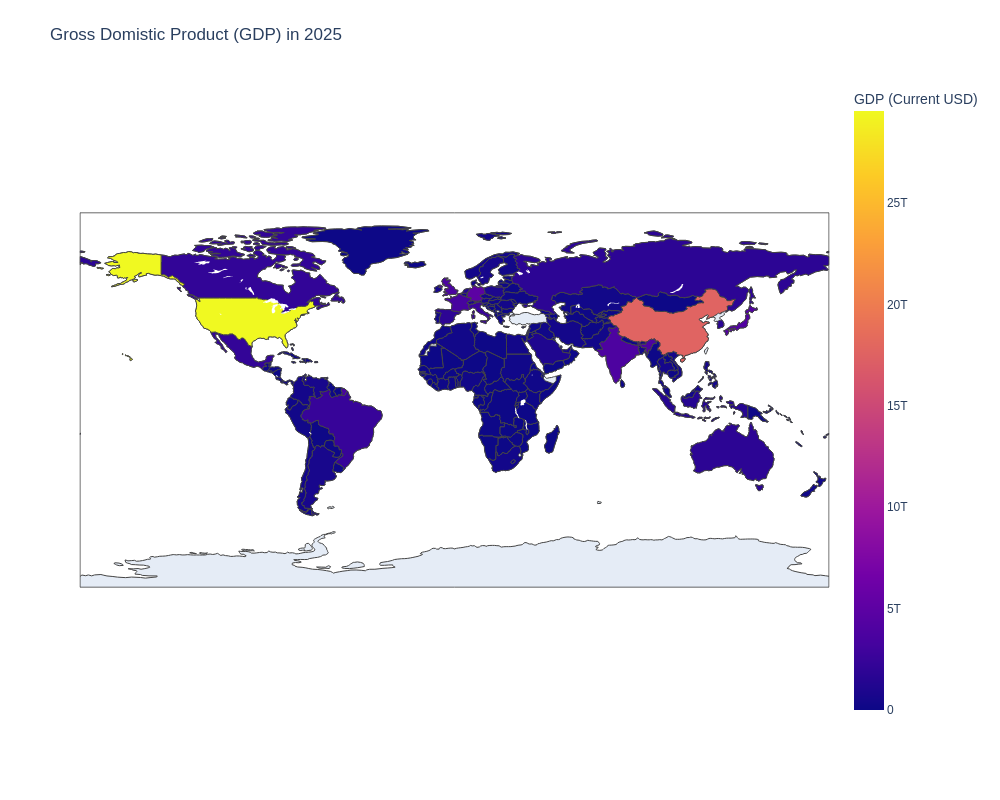

In [45]:
df_2025 = data[data['year'] == 2025]
fig = px.choropleth(df_2025, locations="country_name",
                    color="GDP (Current USD)",
                    locationmode='country names',
                    hover_name="country_name",
                    title="Gross Domistic Product (GDP) in 2025",
                    color_discrete_sequence=px.colors.sequential.Inferno)

fig.update_layout(width=1000,height=800,margin=dict(l=80, r=80, t=80, b=80))

fig.write_image("fig1_chart.png", engine="kaleido")
display(Image(filename="fig1_chart.png"))

fig.write_html("fig1_chart.html")

Top 10 biggest economies in 2025:
country_name
United States     2.954746e+13
China             1.770821e+13
Germany           4.919304e+12
Japan             4.153212e+12
India             3.795300e+12
United Kingdom    3.670527e+12
France            3.330712e+12
Italy             2.517518e+12
Brazil            2.420598e+12
Mexico            2.185961e+12
Name: GDP (Current USD), dtype: float64



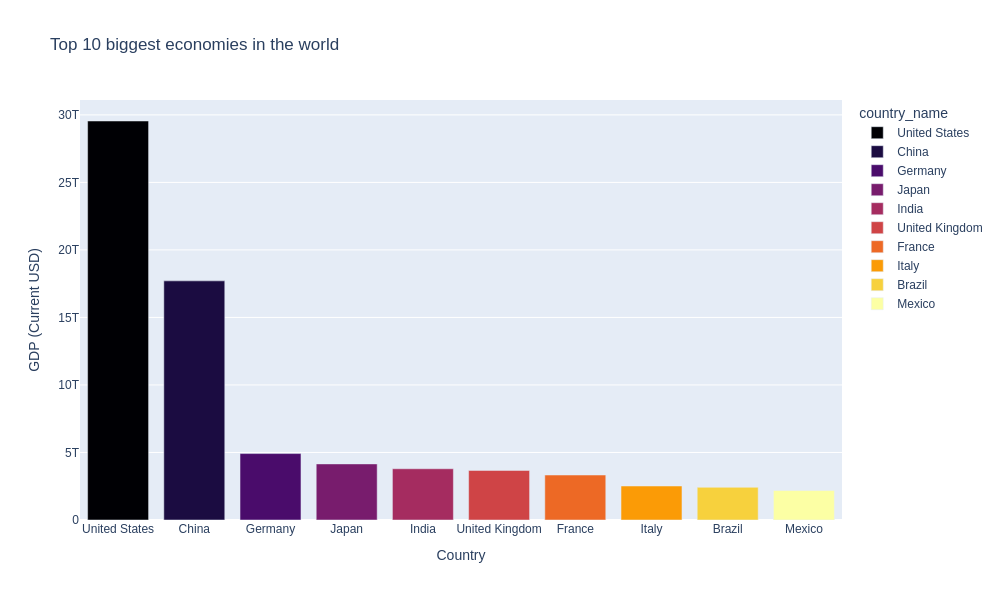

In [46]:
GDP_gr= data[data['year'] ==2025].groupby('country_name')['GDP (Current USD)'].sum().round(2).sort_values(ascending=False).head(10)
print(f'Top 10 biggest economies in 2025:\n{GDP_gr}')
print()

# Visualization

fig = px.bar(GDP_gr,x=GDP_gr.index,y=GDP_gr.values,color=GDP_gr.index,color_discrete_sequence=px.colors.sequential.Inferno,
    title='Top 10 biggest economies in the world',
    hover_name=GDP_gr.index,hover_data=['GDP (Current USD)'])

fig.update_layout( width=1000,
    height=600,
    xaxis_title='Country',
    yaxis_title='GDP (Current USD)')


fig.write_image("fig2_chart.png", engine="kaleido")
display(Image(filename="fig2_chart.png"))

fig.write_html("fig2_chart.html")

US and China control the global economy

`GDP trend over the years`

Gross National Product (GDP) over the years: 
year
2010    6.614079e+13
2011    7.356971e+13
2012    7.518291e+13
2013    7.733227e+13
2014    7.945572e+13
2015    7.527581e+13
2016    7.650106e+13
2017    8.144451e+13
2018    8.657920e+13
2019    8.783154e+13
2020    8.539378e+13
2021    9.732236e+13
2022    1.012343e+14
2023    1.056338e+14
2024    1.107538e+14
2025    1.107538e+14
Name: GDP (Current USD), dtype: float64



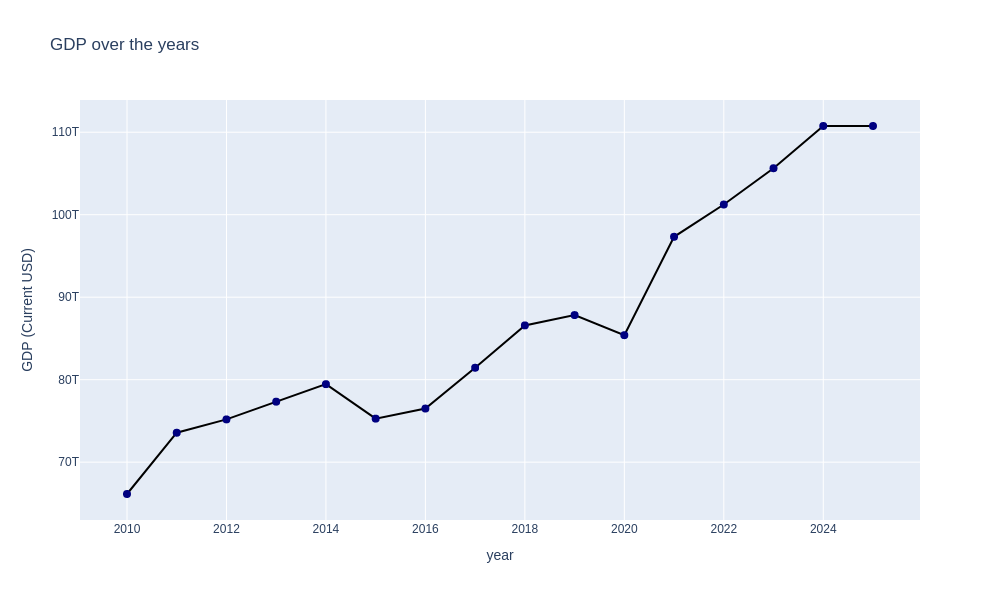

In [47]:
GDPy_gr=data.groupby('year')['GDP (Current USD)'].sum()
print(f'Gross National Product (GDP) over the years: \n{GDPy_gr}')
print()

# Visualization

fig = px.line(GDPy_gr,x=GDPy_gr.index,y=GDPy_gr.values,markers=True,
              labels={'x': 'Year', 'y': 'GDP (Current USD)'},title='GDP over the years')

fig.update_layout(width=1000,
    height=600)

fig.update_traces(marker=dict(color='navy',size=8),
    line=dict(color='black',width=2))

fig.write_image("fig3_chart.png", engine="kaleido")
display(Image(filename="fig3_chart.png"))

fig.write_html("fig3_chart.html")

`GDP world contribution`

Gross National Product per continent:continent
Africa     4.129734e+13
America    4.694091e+14
Asia       4.898290e+14
Europe     3.619142e+14
Oceania    2.795576e+13
Name: GDP (Current USD), dtype: float64



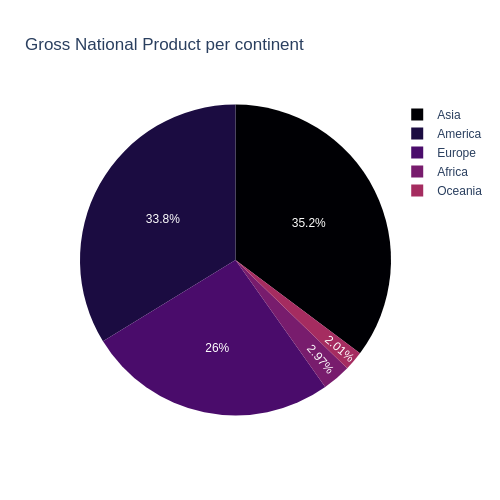

In [48]:
GDPyc_gr=data.groupby('continent')['GDP (Current USD)'].sum()
print(f'Gross National Product per continent:{GDPyc_gr}')
print()

# Visualization

fig = px.pie(data,values=GDPyc_gr.values,names=GDPyc_gr.index, title="Gross National Product per continent",
             color_discrete_sequence=px.colors.sequential.Inferno)
fig.update_layout( width=500,
    height=500)


fig.write_image("fig4_chart.png", engine="kaleido")
display(Image(filename="fig4_chart.png"))

fig.write_html("fig4_chart.html")

`GDP per capita`

Top 10 economies with highest per capita GDP: 
country_name
Monaco            186619.4900
Liechtenstein     171685.3500
Luxembourg        117965.2135
Bermuda           110543.3910
Norway             87925.0940
Switzerland        86601.0575
Isle of Man        85940.5355
Cayman Islands     81196.3710
Qatar              78791.6010
Ireland            76873.8205
Name: per capita GDP, dtype: float64



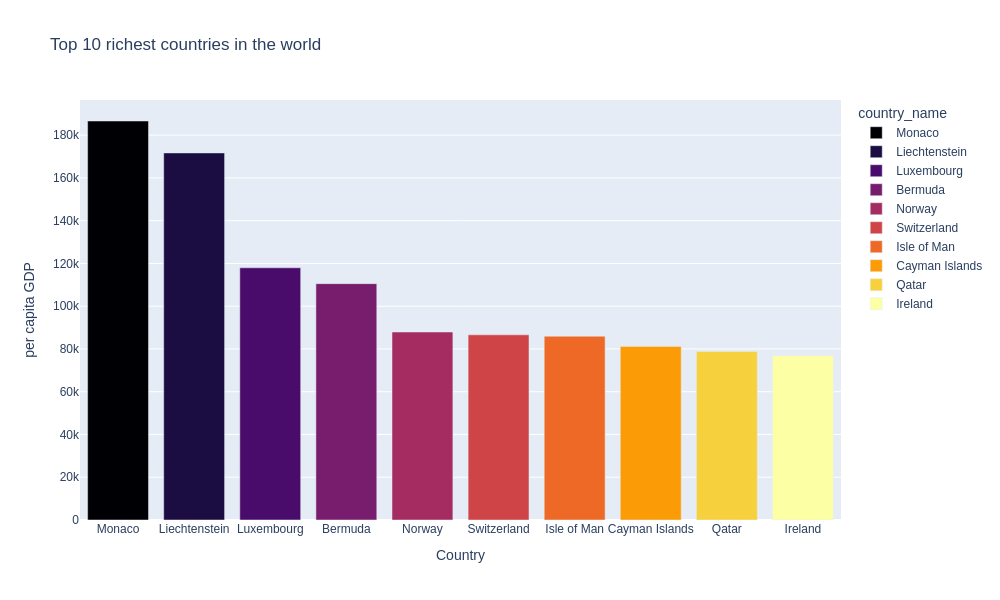

In [49]:
per_gr=data.groupby('country_name')['per capita GDP'].median().sort_values(ascending=False).head(10)
print(f'Top 10 economies with highest per capita GDP: \n{per_gr}')
print()

# Visualization

fig = px.bar(per_gr,x=per_gr.index,y=per_gr.values,color=per_gr.index,color_discrete_sequence=px.colors.sequential.Inferno,
    title='Top 10 richest countries in the world',
    hover_name=per_gr.index,hover_data=['per capita GDP'])

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Country',
    yaxis_title='per capita GDP')


fig.write_image("fig5_chart.png", engine="kaleido")
display(Image(filename="fig5_chart.png"))

fig.write_html("fig5_chart.html")

Monaco, Liechtenstein and Luxembourg are the richest countries in the world according to the per capita GDP

per capita GDP over the years: 
year
2010    5664.0900
2011    6504.2820
2012    6552.8895
2013    6924.3750
2014    7134.5345
2015    6147.8500
2016    5971.1065
2017    6513.7845
2018    6946.3345
2019    6820.9585
2020    6433.0895
2021    7054.6355
2022    7630.9160
2023    7979.7980
2024    7979.7980
2025    7979.7980
Name: per capita GDP, dtype: float64



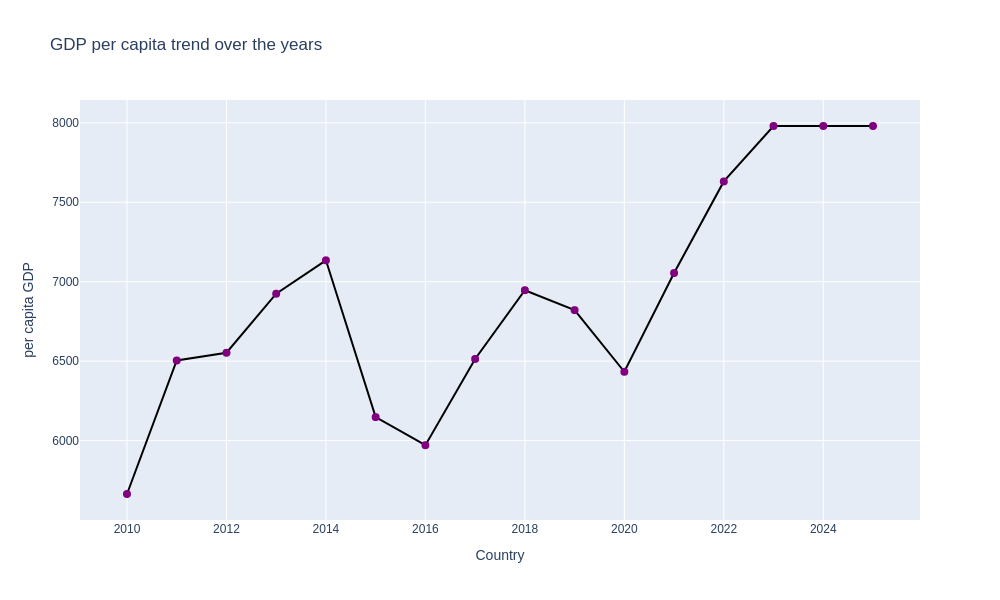

In [50]:
pery_gr = data.groupby('year')['per capita GDP'].median()
print(f'per capita GDP over the years: \n{pery_gr}')
print()
# Visualization

fig = px.line(pery_gr,x=pery_gr.index,y=pery_gr.values,markers=True
              ,title='GDP per capita trend over the years')

fig.update_layout(width=1000,
    height=600,xaxis_title='Country',
    yaxis_title='per capita GDP')

fig.update_traces(marker=dict(color='purple',size=8),
    line=dict(color='black',width=2))


fig.write_image("fig6_chart.png", engine="kaleido")
display(Image(filename="fig6_chart.png"))

fig.write_html("fig6_chart.html")

`GDP growth`

GDP growth per continent:
continent
Africa     5.85
America    5.34
Asia       5.94
Europe     4.94
Oceania    4.84
Name: GDP Growth (% Annual), dtype: float64


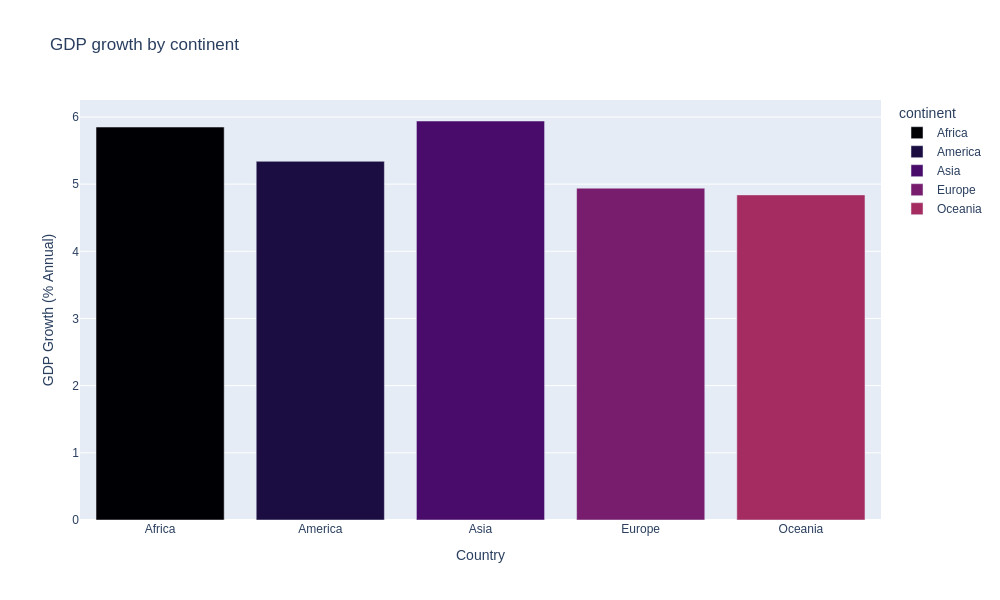

In [51]:
GDR = data.groupby('continent')['GDP Growth (% Annual)'].mean().round(2)
print(f'GDP growth per continent:\n{GDR}')

# Visualization

fig = px.bar(GDR,x=GDR.index,y=GDR.values,color=GDR.index,color_discrete_sequence=px.colors.sequential.Inferno,
    title='GDP growth by continent',
    hover_name=GDR.index,hover_data=['GDP Growth (% Annual)'])

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Country',
    yaxis_title='GDP Growth (% Annual)')


fig.write_image("fig7_chart.png", engine="kaleido")
display(Image(filename="fig7_chart.png"))

fig.write_html("fig7_chart.html")

`Gross domestic product (GDP) vs Gross National Income (USD)`

Gross Domestic Product (GDP) and Gross National Income (USD) correlation : 0.9968499617365268



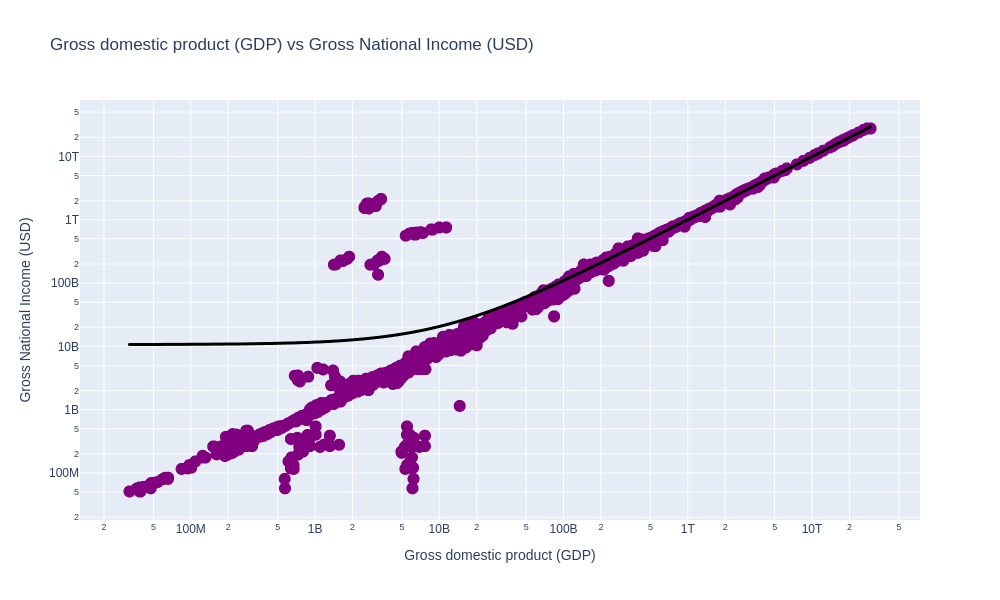

In [52]:
corr = data['GDP (Current USD)'].corr(data['Gross National Income (USD)'])
print(f'Gross Domestic Product (GDP) and Gross National Income (USD) correlation : {corr}')
print()

# Visualization

fig = px.scatter(data, x='GDP (Current USD)',y="Gross National Income (USD)",
                 log_x=True,log_y=True,title="Gross domestic product (GDP) vs Gross National Income (USD)",
                  trendline='ols',hover_name='country_name')

fig.update_traces(marker=dict(size=12, color='purple'), selector=dict(mode='markers'))
fig.update_traces(line=dict(color='black', width=3), selector=dict(mode='lines'))

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Gross domestic product (GDP)',
    yaxis_title='Gross National Income (USD)')


fig.write_image("fig8_chart.png", engine="kaleido")
display(Image(filename="fig8_chart.png"))

fig.write_html("fig8_chart.html")

`Inflation (GDP Deflator%) vs Unemployment Rate (%)`

Inflation (GDP Deflator, %) and Unemployment Rate (%) correlaion : 0.021173473638900778



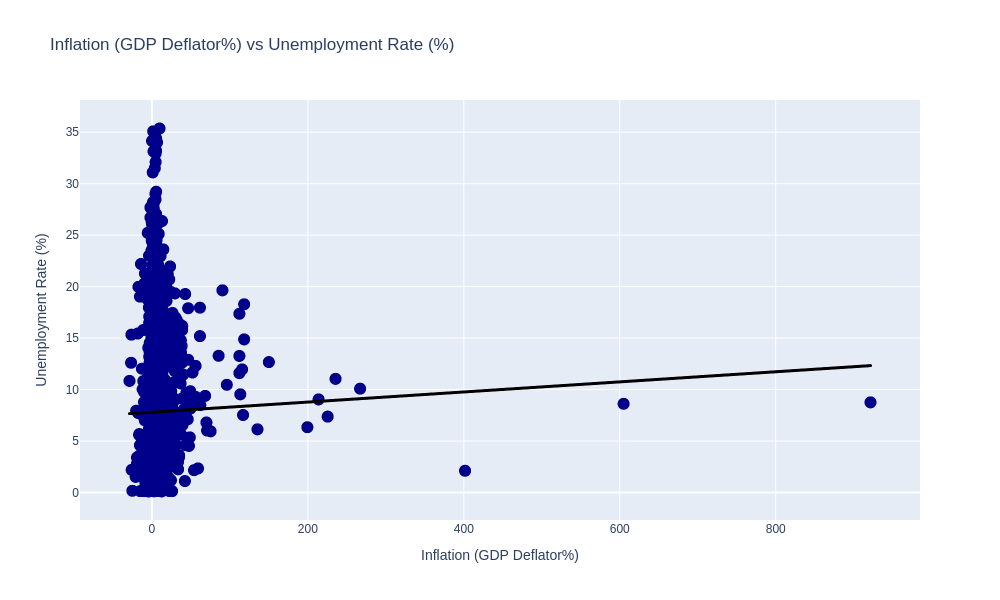

In [53]:
corr = data['Inflation (GDP Deflator, %)'].corr(data['Unemployment Rate (%)'])
print(f'Inflation (GDP Deflator, %) and Unemployment Rate (%) correlaion : {corr}')
print()

# Visualization

fig = px.scatter(data,x="Inflation (GDP Deflator, %)",y='Unemployment Rate (%)',
                 title="Inflation (GDP Deflator%) vs Unemployment Rate (%)",
                  trendline='ols',hover_name="country_name")

fig.update_traces(marker=dict(size=12, color='darkblue'), selector=dict(mode='markers'))
fig.update_traces(line=dict(color='black', width=3), selector=dict(mode='lines'))

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Inflation (GDP Deflator%)',
    yaxis_title='Unemployment Rate (%)')


fig.write_image("fig9_chart.png", engine="kaleido")
display(Image(filename="fig9_chart.png"))

fig.write_html("fig9_chart.html")

` Inflation rates over the world `

Inflation rate per country:
 country_name
Sudan                   34.3445
Argentina               33.3315
Syrian Arab Republic    29.0080
Iran, Islamic Rep.      24.7235
Yemen, Rep.             16.4840
Angola                  15.6655
Ukraine                 14.7905
Uzbekistan              13.8590
Ghana                   13.5840
Malawi                  13.0585
Name: Inflation (GDP Deflator, %), dtype: float64



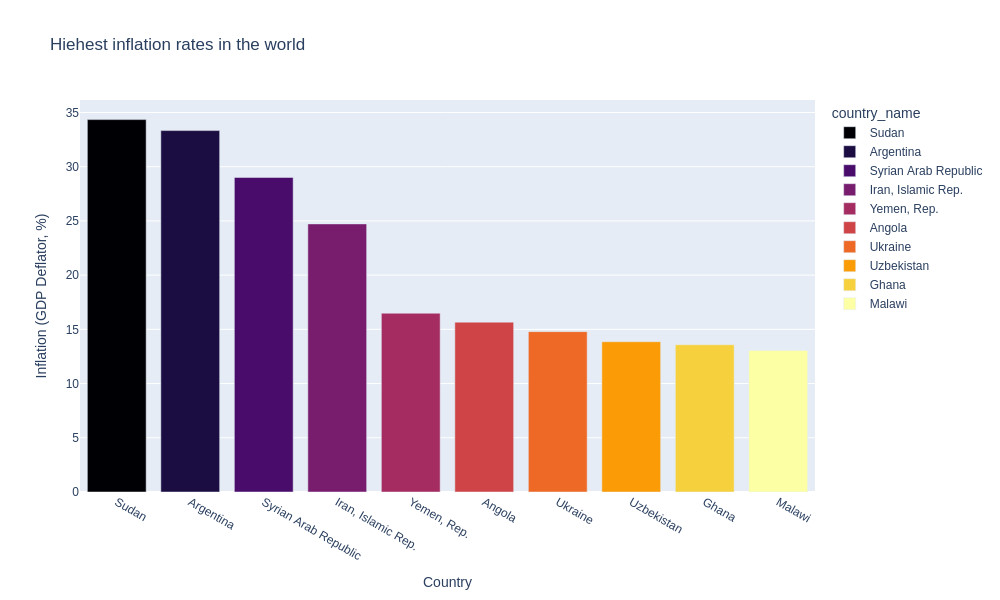

In [54]:
infgr = data.groupby('country_name')['Inflation (GDP Deflator, %)'].median().sort_values(ascending=False).head(10)
print(f'Inflation rate per country:\n {infgr}')
print()

# Visualizaion

fig = px.bar(infgr,x=infgr.index,y=infgr.values,color=infgr.index,
             color_discrete_sequence=px.colors.sequential.Inferno,
             title='Hiehest inflation rates in the world',hover_name=infgr.index,hover_data=['Inflation (GDP Deflator, %)'])

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Country',
    yaxis_title='Inflation (GDP Deflator, %)')


fig.write_image("fig10_chart.png", engine="kaleido")
display(Image(filename="fig10_chart.png"))

fig.write_html("fig10_chart.html")

Due to political and economic instability, and wars, countries like Syria, Sudan, Iran, Yemen, and Ukraine experienced a high inflation rate

`fiscal balance % GDP' vs 'Current Account Balance (% GDP)`

fiscal balance and Current Account Balance correlaion : 0.5735058002413743



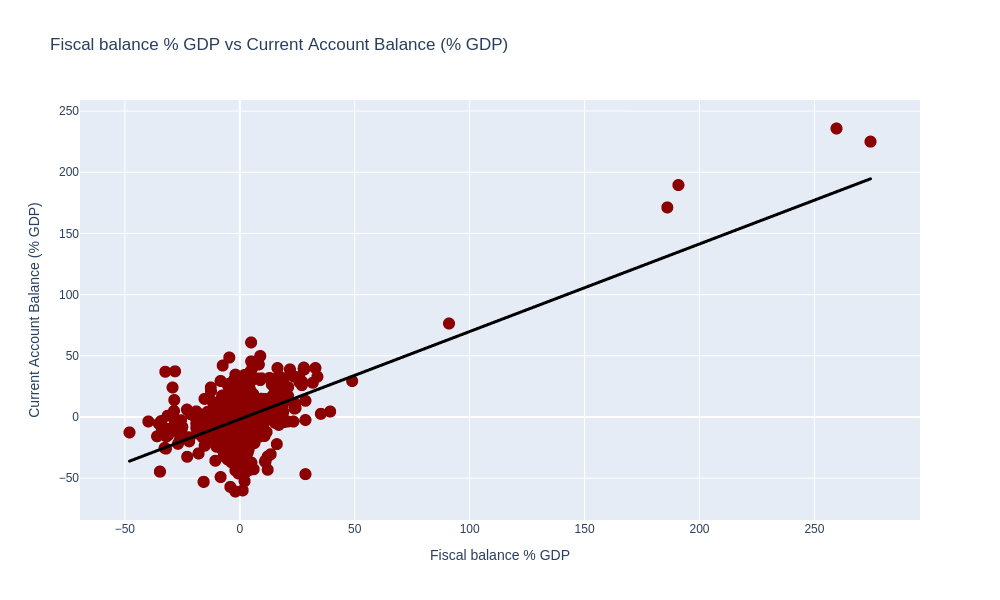

In [55]:
corr = data['fiscal balance % GDP'].corr(data['Current Account Balance (% GDP)'])
print(f'fiscal balance and Current Account Balance correlaion : {corr}')
print()

# Visualization

fig = px.scatter(data,x="fiscal balance % GDP",y='Current Account Balance (% GDP)',
                 title="Fiscal balance % GDP vs Current Account Balance (% GDP)",
                  trendline='ols',hover_name="country_name")

fig.update_traces(marker=dict(size=12, color='darkred'), selector=dict(mode='markers'))
fig.update_traces(line=dict(color='black', width=3), selector=dict(mode='lines'))

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Fiscal balance % GDP',
    yaxis_title='Current Account Balance (% GDP)')


fig.write_image("fig11_chart.png", engine="kaleido")
display(Image(filename="fig11_chart.png"))

fig.write_html("fig11_chart.html")

`Who runs surplus and who runs deficit`

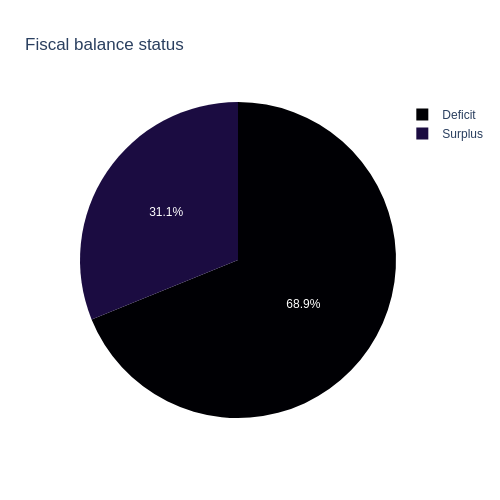

In [56]:
df = data.groupby('country_name')['fiscal balance % GDP'].median()
total = len(df)
deficit = (df<0).sum()
surplus = (df>0).sum()
labels = ['Deficit', 'Surplus']
sizes = [deficit,surplus]

# Visualization

fig = px.pie(df,values=sizes,names=labels, title="Fiscal balance status",
             color_discrete_sequence=px.colors.sequential.Inferno)
fig.update_layout( width=500,
    height=500)


fig.write_image("fig12_chart.png", engine="kaleido")
display(Image(filename="fig12_chart.png"))

fig.write_html("fig12_chart.html")

`Givernment revenue and expense`

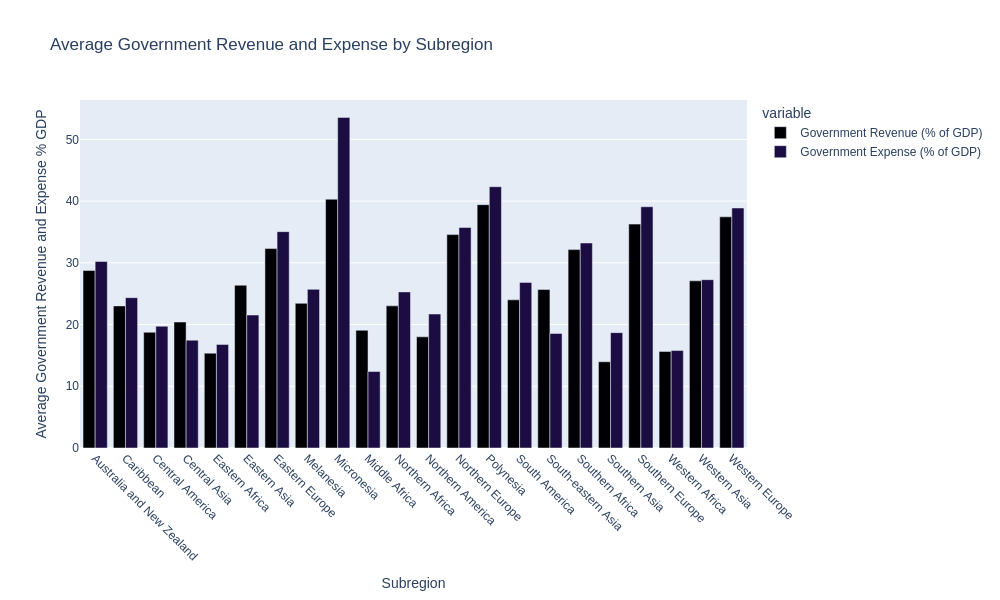

In [57]:
GE = data.groupby('subregion')[['Government Revenue (% of GDP)', 'Government Expense (% of GDP)']].mean().round(2).reset_index()
# Visualization
fig = px.bar(GE,x='subregion',y=['Government Revenue (% of GDP)', 'Government Expense (% of GDP)'],barmode='group',
             color_discrete_sequence=px.colors.sequential.Inferno,
    title='Average Government Revenue and Expense by Subregion')

fig.update_layout(width=1000,height=600,xaxis_title='Subregion',
                  yaxis_title='Average Government Revenue and Expense % GDP',xaxis_tickangle=45)


fig.write_image("fig13_chart.png", engine="kaleido")
display(Image(filename="fig13_chart.png"))

fig.write_html("fig13_chart.html")

`Government revenue vs Tax revenue`

Government Revenue (% of GDP) and Tax Revenue (% of GDP)correlation : 0.7464766196255339



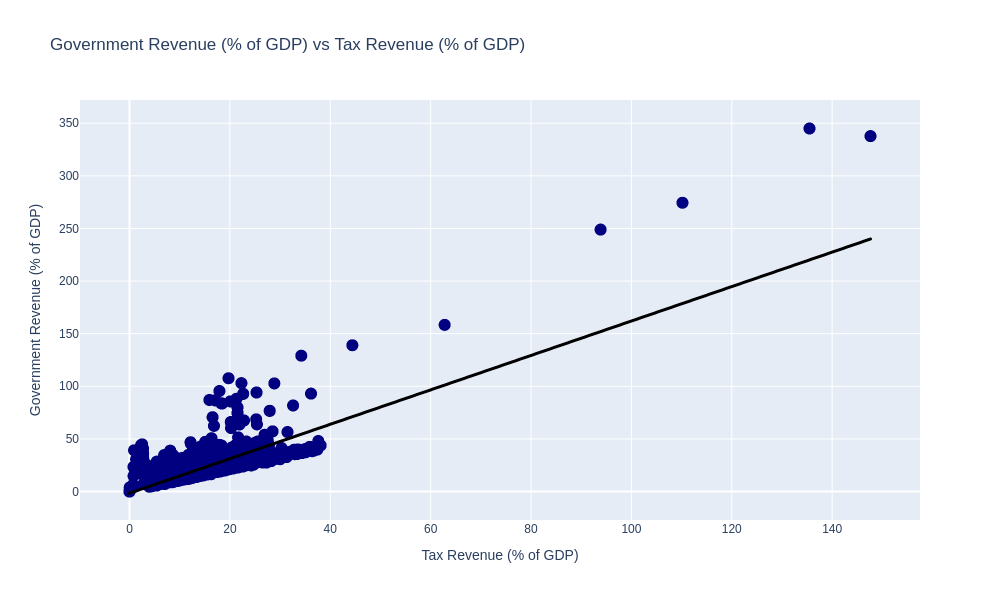

In [58]:
corr = data['Government Revenue (% of GDP)'].corr(data['Tax Revenue (% of GDP)'])
print(f'Government Revenue (% of GDP) and Tax Revenue (% of GDP)correlation : {corr}')
print()

# Visualization

fig = px.scatter(data,x="Tax Revenue (% of GDP)",y='Government Revenue (% of GDP)',
                 title="Government Revenue (% of GDP) vs Tax Revenue (% of GDP)",
                  trendline='ols',hover_name="country_name")

fig.update_traces(marker=dict(size=12, color='navy'), selector=dict(mode='markers'))
fig.update_traces(line=dict(color='black', width=3), selector=dict(mode='lines'))

fig.update_layout(width=1000,
    height=600,
    xaxis_title='Tax Revenue (% of GDP)',
    yaxis_title='Government Revenue (% of GDP)')


fig.write_image("fig14_chart.png", engine="kaleido")
display(Image(filename="fig14_chart.png"))

fig.write_html("fig14_chart.html")

# Insights



*   Global GDP and GDP per capita have steadily increased over the past 15 years, indicating overall economic growth and improving average income levels worldwide.

*   Asia and Europe together account for more than 75% of the global economy, making them the dominant players in global output.

*   Asian and African markets are growing faster than the U.S. and Europe. This is typical, as emerging markets tend to achieve higher growth rates compared to more mature economies.

*   There is a strong positive relationship between GDP and GNI — as economic output increases, national income tends to rise as well.


*   High inflation in many countries is often linked to wars and political instability, which disrupt economic activity and drive prices up.


*   There appears to be little to no clear relationship between inflation and unemployment in the data, suggesting the connection is not consistent across countries.

*   Fiscal balance and current account balance show a strong positive correlation, meaning countries tend to run similar patterns in both.

*   Most countries operate with fiscal deficits. The key issue is not the deficit itself, but its size and how it is financed.

*   Tax revenue is strongly correlated with government revenue, as it represents a major source of income for governments.






